# Medical Insurance Cost Prediction (CRISP-DM)
*Predicting and explaining annual medical insurance costs.*

A Machine Learning solution predicts annual medical insurance cost in USD. The estimate must be accurate enough to support premium pricing and transparent enough that the contribution of each attribute to an individual quote can be explained to underwriters, customers, and regulators. Leveraging Shapley values to explain attributes contribution and R2/RMSE as evaluation metrics.

The pipeline follows CRISP-DM:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

---

## Phase 1: Business Understanding

Objective: Estimate a person's annual medical cost from basic profile and health attributes, so an insurer can price premiums, flag high-cost cases, and explain every quote.

Business context: Insurers need to set premiums that cover expected costs without overcharging customers. A reliable cost estimate helps price policies fairly, identify customers likely to incur high costs, and support reserving and budgeting decisions.

Stakeholders: Underwriters who set prices, customers who receive quotes, and regulators who require that pricing be justified and non-arbitrary.

Business success criteria: Cost estimates are close enough to actual charges to guide pricing decisions, and each quote can be explained in terms of the customer attributes that drove it, so the insurer can defend its pricing to customers and regulators.


## Phase 2: Data Understanding

Goal of this phase: get familiar with the data before modeling. We load the dataset, inspect its structure and types, check for missing and duplicate values, and review how each attribute is distributed and how it relates to charges.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Structure and data types
print("Shape:", df.shape)
df.info()

Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
# Summary statistics for numeric and categorical columns
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [4]:
# Data quality: missing values and duplicates
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [5]:
for var in ['smoker', 'sex', 'region']:
    print(df[var].value_counts(normalize=True).map("{:.2%}".format), '\n')

smoker
no     79.52%
yes    20.48%
Name: proportion, dtype: object 

sex
male      50.52%
female    49.48%
Name: proportion, dtype: object 

region
southeast    27.20%
southwest    24.29%
northwest    24.29%
northeast    24.22%
Name: proportion, dtype: object 



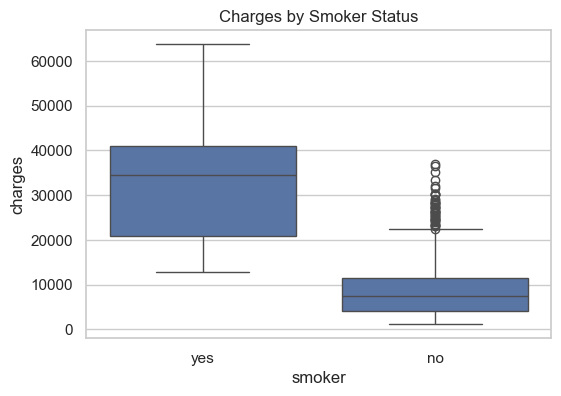

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Charges by Smoker Status")
plt.show()

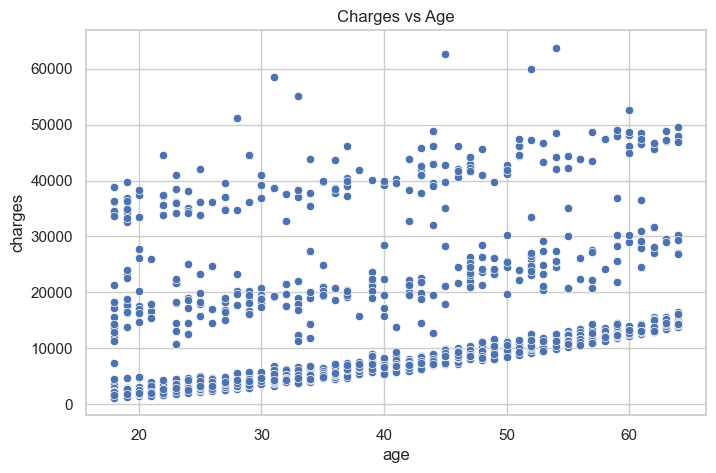

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="charges")
plt.title("Charges vs Age")
plt.show()

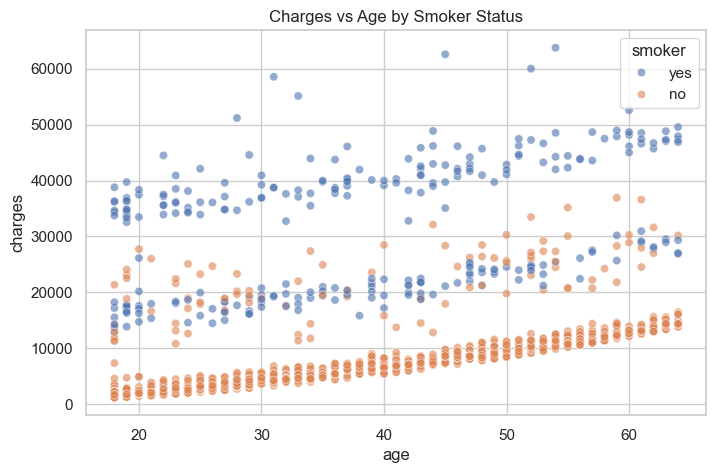

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.6)
plt.title("Charges vs Age by Smoker Status")
plt.show()

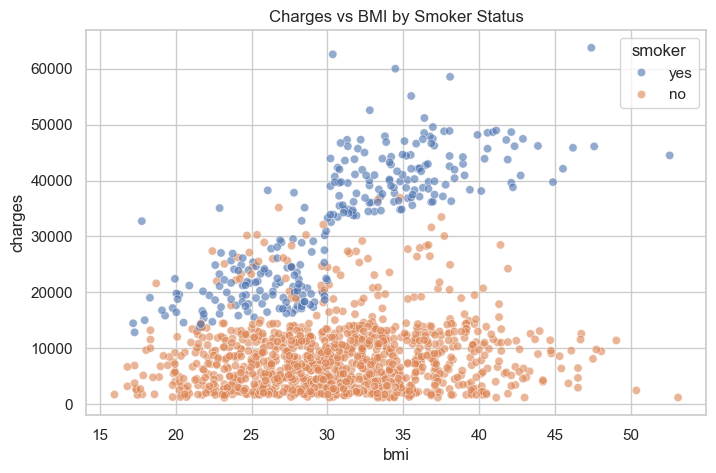

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker",
    alpha=0.6
)
plt.title("Charges vs BMI by Smoker Status")
plt.show()

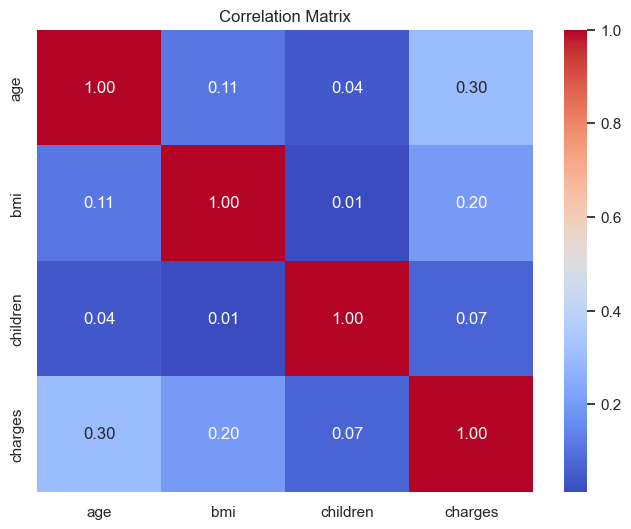

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Phase 2 conclusions

What the EDA tells us:

- Data quality: no missing values, with a single duplicate row to drop in preparation.
- Skewed target: charges are right-skewed, with the mean sitting well above the median because of a long tail of high-cost cases.
- Smoker dominance: smoking is the single strongest driver of cost. Smokers are charged several times more than non-smokers, dwarfing the effect of any other attribute.
- Smoker-by-BMI interaction: BMI barely moves cost for non-smokers, but among smokers higher BMI raises cost sharply. The effect of BMI depends on smoking status, so the two should not be treated as independent.


## Phase 3: Data Preparation

Goal of this phase: fix the issues identified in Phase 2 and prepare the feature matrix for modeling.

The template followed for data preparation (cleaning and transforming) is:

- Handle duplicates and missing values: the dataset has no missing values and one duplicate row to drop.
- Encode categorical variables:
  - `sex` and `smoker` are binary, so map them to 0/1.
  - `region` is nominal with four levels, so apply one-hot encoding.
- Feature engineering:
  - Log transformation `charges` is right skewed.
  - add `smoker * bmi` to capture the interaction seen in the EDA.
  - optionally add an `obese` flag (and `obese * smoker`) based on BMI standards.


In [11]:
print("Rows before:", len(df))

df = df.drop_duplicates()

print("Rows after:", len(df))

Rows before: 1338
Rows after: 1337


In [12]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df["sex"] = df["sex"].map({"female": 0, "male": 1})

In [13]:
df.region.value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [14]:
df = pd.get_dummies(
    df,
    columns=["region"],
    dtype=int
)
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


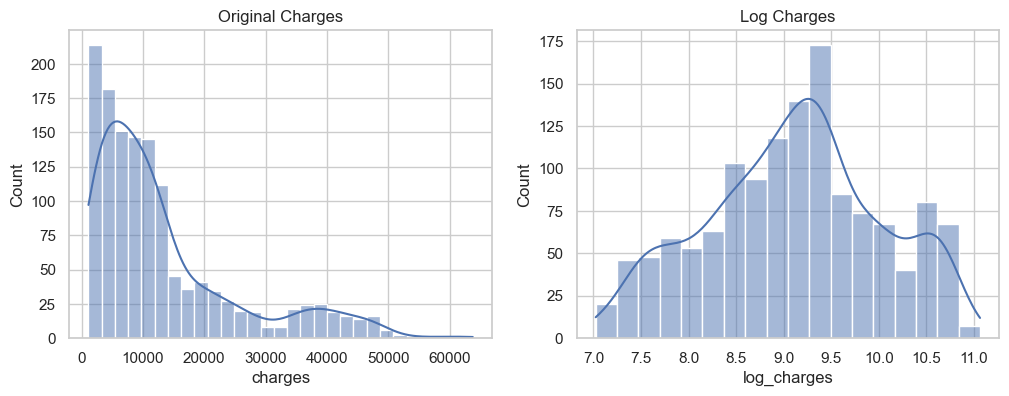

In [15]:
df["log_charges"] = np.log1p(df["charges"])

ig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["charges"], kde=True, ax=axes[0])
axes[0].set_title("Original Charges")

sns.histplot(df["log_charges"], kde=True, ax=axes[1])
axes[1].set_title("Log Charges")

plt.show()

In [16]:
# BMI-smoker interaction
df["bmi_smoker"] = df["bmi"] * df["smoker"]

# Obesity flag (BMI >= 30)
df["obese"] = (df["bmi"] >= 30).astype(int)

# Obesity-smoker interaction
df["obese_smoker"] = df["obese"] * df["smoker"]

## Phase 4: Modeling

Goal of this phase: fit models, starting simple and adding complexity only when it earns its place.

The approach is:

- Fit linear regression on the engineered feature set (including the `bmi_smoker` interaction and the obesity flags), predicting charges in dollars.
- Compare it against a no-interaction baseline and against Ridge and Lasso, to see whether the interaction helps and whether regularization changes anything.
- Compare with a Random Forest to see what a non-linear model achieves.
- All results are printed (R2 and RMSE in dollars) so the variants can be read off directly.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

def split(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Linear regression with the engineered interaction features, predicting charges in dollars
features = ['age', 'sex', 'bmi', 'children', 'smoker',
            'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest',
            'bmi_smoker', 'obese', 'obese_smoker']

X_train, X_test, y_train, y_test = split(df[features], df['charges'])

lr = LinearRegression().fit(X_train, y_train)
pred = lr.predict(X_test)

print('Linear Regression with interaction features')
print('R2:  ', round(r2_score(y_test, pred), 4))
print('RMSE: $', round(np.sqrt(mean_squared_error(y_test, pred)), 2))

Linear Regression with interaction features
R2:   0.9092
RMSE: $ 4085.44


In [19]:
# Comparison of model variants, all scored on the test set in dollars
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

base = ['age', 'sex', 'bmi', 'children', 'smoker',
        'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
full = base + ['bmi_smoker', 'obese', 'obese_smoker']

def evaluate(name, model, cols):
    X_tr, X_te, y_tr, y_te = split(df[cols], df['charges'])
    model.fit(X_tr, y_tr)
    p = model.predict(X_te)
    r2 = r2_score(y_te, p)
    rmse = np.sqrt(mean_squared_error(y_te, p))
    print(f"{name:<32s} R2 = {r2:.4f}   RMSE = ${rmse:,.0f}")

evaluate('Baseline LR (no interaction)', LinearRegression(), base)
evaluate('LR + interaction',             LinearRegression(), full)
evaluate('Ridge + interaction (scaled)', make_pipeline(StandardScaler(), Ridge(alpha=1.0)), full)
evaluate('Lasso + interaction (scaled)', make_pipeline(StandardScaler(), Lasso(alpha=1.0)), full)

Baseline LR (no interaction)     R2 = 0.8069   RMSE = $5,956
LR + interaction                 R2 = 0.9092   RMSE = $4,085
Ridge + interaction (scaled)     R2 = 0.9092   RMSE = $4,084
Lasso + interaction (scaled)     R2 = 0.9092   RMSE = $4,084


In [20]:
# Random Forest for comparison (captures the smoker-by-BMI interaction on its own)
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = split(df[full], df['charges'])

rf = RandomForestRegressor(n_estimators=100, random_state=1, n_jobs=-1).fit(X_train, y_train)
pred = rf.predict(X_test)

print('Random Forest Regressor')
print('R2:  ', round(r2_score(y_test, pred), 4))
print('RMSE: $', round(np.sqrt(mean_squared_error(y_test, pred)), 2))

Random Forest Regressor
R2:   0.8816
RMSE: $ 4664.04


## Phase 5: Evaluation

Goal of this phase: judge the chosen model against the Phase 1 success criteria and explain how it reaches its predictions.

The chosen model is linear regression with the interaction features, predicting charges in dollars. We:

- Score it on the held-out test set (R2 and RMSE in dollars) and check it against the target of R2 at least 0.80.
- Read the coefficients and p-values to confirm the drivers make business sense.
- Inspect the residuals for any obvious pattern.
- Use Shapley values to explain the predictions, both overall and for a single customer.


In [21]:
# Final model: linear regression with interaction features, predicting charges in dollars
features = ['age', 'sex', 'bmi', 'children', 'smoker',
            'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest',
            'bmi_smoker', 'obese', 'obese_smoker']

X_train, X_test, y_train, y_test = split(df[features], df['charges'])

final_model = LinearRegression().fit(X_train, y_train)
pred = final_model.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print('Final model: Linear Regression with interaction features')
print('R2:  ', round(r2, 4))
print('RMSE: $', round(rmse, 2))
print('Phase 1 target (R2 >= 0.80):', 'PASS' if r2 >= 0.80 else 'FAIL')

Final model: Linear Regression with interaction features
R2:   0.9092
RMSE: $ 4085.44
Phase 1 target (R2 >= 0.80): PASS


In [22]:
# Inference with statsmodels: coefficients, p-values, and confidence intervals
import statsmodels.api as sm

ols = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     557.9
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:23:23   Log-Likelihood:                -10506.
No. Observations:                1069   AIC:                         2.104e+04
Df Residuals:                    1057   BIC:                         2.109e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1172.0811    949.362  

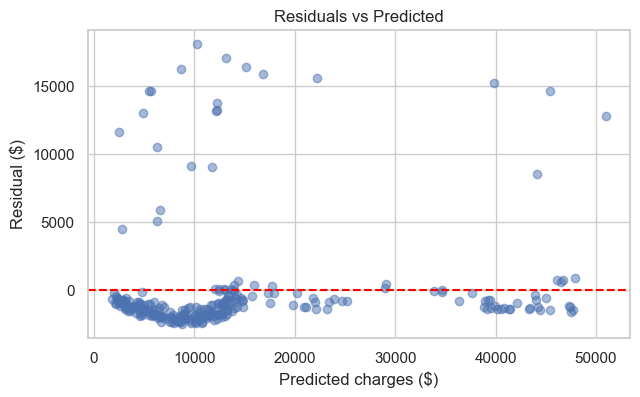

In [23]:
# Residuals: errors should scatter around zero with no obvious pattern
residuals = y_test - pred

plt.figure(figsize=(7, 4))
plt.scatter(pred, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted charges ($)")
plt.ylabel("Residual ($)")
plt.title("Residuals vs Predicted")
plt.show()

Background dataset has 1069 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1069 when initializing the masker.


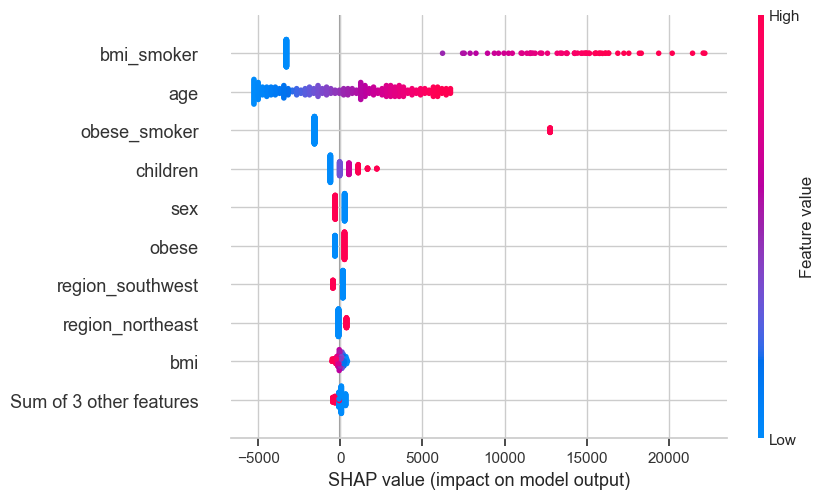

In [24]:
# Explainability with SHAP: how each feature pushes a prediction up or down
import shap

explainer = shap.LinearExplainer(final_model, X_train)
shap_values = explainer(X_test)

# Overall view: which features matter most across all test customers
shap.plots.beeswarm(shap_values)

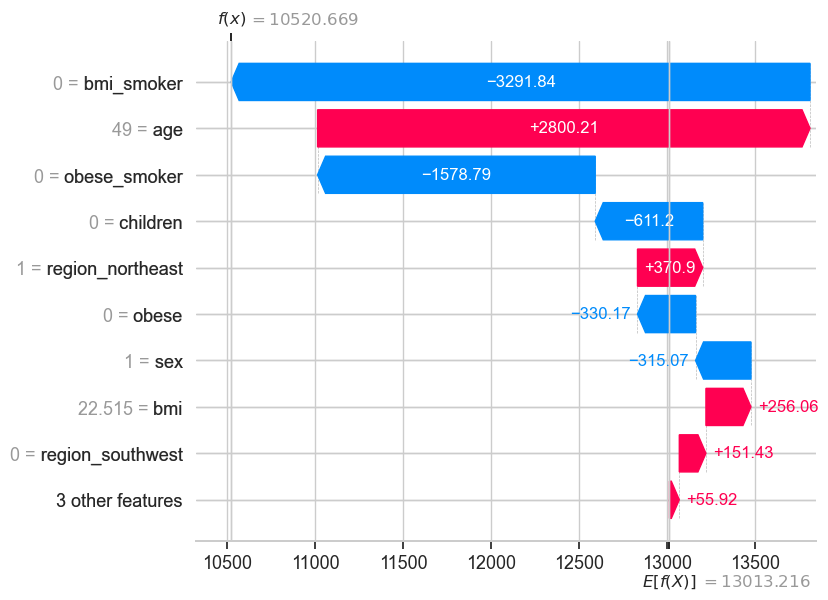

In [25]:
# Explain a single customer's quote: why this prediction is what it is
shap.plots.waterfall(shap_values[0])

### Evaluation summary

- Performance: the linear model with interaction features reaches an R2 of about 0.91 and an RMSE near 4,100 dollars on the test set, clearing the Phase 1 target of 0.80.
- Drivers make sense: the smoker-by-BMI interaction and the obesity-smoker flag carry most of the cost, followed by age. Once these interactions are in the model, the plain `smoker` term loses significance because the smoking effect now flows through them rather than through smoking alone.
- Residuals: errors scatter around zero, with the largest misses among the highest-cost customers, which is expected for a small linear model.
- Explainability: SHAP confirms the same story at two levels. The overall view ranks the smoker-by-BMI interaction, age, and the obesity-smoker flag as the top drivers, and the single-customer view breaks one quote into the exact dollar push from each attribute, which is what an insurer needs to justify a price.


## Phase 6: Deployment

Goal of this phase: make the model usable and plan how it would run in practice.

- Save the trained model so it can be reused without retraining.
- Wrap prediction in a small function that takes a customer profile and returns an estimated annual cost in dollars.
- In production the model would sit behind the quoting system. Each quote can store its SHAP explanation for audit, so the price stays defensible. Input drift (a changing age or BMI mix) should be monitored and the model refit periodically.
- Limitations: the model is trained on 1,337 US records with six attributes, so it should not be applied outside that population, and it predicts an expected cost rather than a certainty for any single person.

The project is published in two places:

- Code and saved model: [github.com/Abdu114hf16/medical-insurance-cost-prediction](https://github.com/Abdu114hf16/medical-insurance-cost-prediction)
- Non-technical write-up (blog post): [alshammari.dev/blog/medical-cost-prediction.html](https://alshammari.dev/blog/medical-cost-prediction.html)


In [26]:
# Save the trained model and wrap it in a simple prediction function
import joblib

joblib.dump(final_model, "medical_cost_model.joblib")

def predict_cost(profile):
    """Estimate annual medical cost in USD for a single customer profile.

    profile: dict with keys age, sex (0/1), bmi, children, smoker (0/1),
    and region (one of northeast, northwest, southeast, southwest).
    """
    row = {col: 0 for col in features}
    row["age"] = profile["age"]
    row["sex"] = profile["sex"]
    row["bmi"] = profile["bmi"]
    row["children"] = profile["children"]
    row["smoker"] = profile["smoker"]
    row[f"region_{profile['region']}"] = 1
    row["bmi_smoker"] = profile["bmi"] * profile["smoker"]
    row["obese"] = int(profile["bmi"] >= 30)
    row["obese_smoker"] = row["obese"] * profile["smoker"]
    x = pd.DataFrame([row])[features]
    return float(final_model.predict(x)[0])

# Example: a 45-year-old male smoker, BMI 32, 2 children, southeast region
example = {"age": 45, "sex": 1, "bmi": 32, "children": 2, "smoker": 1, "region": "southeast"}
print("Estimated annual cost: $", round(predict_cost(example), 2))

Estimated annual cost: $ 41387.18


## Conclusion

This project followed the full CRISP-DM cycle to predict and explain annual medical insurance cost, and it answers the business questions it set out with:

1. **Can we predict annual cost accurately enough to price premiums?** Yes. A linear regression with interaction features reaches an R2 of about 0.91 and an RMSE near 4,100 dollars on the held-out test set, clearing the 0.80 target set in Phase 1.

2. **What drives medical cost the most?** Smoking, especially when combined with a high BMI. The `bmi_smoker` and `obese_smoker` terms carry the largest effect, followed by age, as both the OLS coefficients and the SHAP values agree.

3. **Does BMI affect everyone equally?** No. BMI barely moves cost for non-smokers but raises it sharply for smokers, which is why the smoker-by-BMI interaction was the single most valuable feature.

4. **Can we explain an individual quote?** Yes. SHAP breaks any prediction into the exact dollar contribution of each attribute, so an insurer can justify a specific price to a customer or regulator.

5. **Is a simple, interpretable model good enough?** Yes. The interpretable linear model (0.91) actually edged out a Random Forest (0.88) here, so we keep the model that is both accurate and easy to explain.

The result is a model that meets the predictive target and satisfies the interpretability requirement that motivated the choice of linear regression in the first place.
